Preprocessing Pipeline and SMOT

In [8]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
import os

# FEATURE 1 — Data Cleaning & Leakage Prevention

df = pd.read_csv("C:\\Users\\DELL\\OneDrive\\Documents\\GitHub\\place-predictor\\data\\Placement_Data_Full_Class.csv")

print("Raw dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution (status):\n", df['status'].value_counts())

df = df.drop(columns=['sl_no', 'salary'])

df['status'] = df['status'].map({'Placed': 1, 'Not Placed': 0})


numerical_cols_raw = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols_raw = df.select_dtypes(include=['object']).columns.tolist()

# Remove target from lists
if 'status' in numerical_cols_raw:
    numerical_cols_raw.remove('status')
if 'status' in categorical_cols_raw:
    categorical_cols_raw.remove('status')

for col in numerical_cols_raw:
    df[col].fillna(df[col].median(), inplace=True)

for col in categorical_cols_raw:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nAfter cleaning — shape:", df.shape)
print("Missing values remaining:", df.isnull().sum().sum())

# FEATURE 2 — Preprocessing Pipeline 

# Separate features and target
X = df.drop(columns=['status'])
y = df['status']

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("\nNumerical features :", numerical_cols)
print("Categorical features:", categorical_cols)


preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
])

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      
)

print(f"\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"Train class dist: {y_train.value_counts().to_dict()}")


# FEATURE 3 — SMOTE (Class Balancing)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed  = preprocessor.transform(X_test)   # transform only, not fit

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_preprocessed, y_train)

print(f"\nAfter SMOTE — Training class distribution:")
print(pd.Series(y_train_res).value_counts().to_dict())
print("(Both classes should now be equal)")
#  store results here
model_results = {}

# (models that include the preprocessor in their own pipeline use X_test,
#  while any model trained on preprocessed arrays uses X_test_preprocessed)
X_test = X_test          # raw — used by imblearn.Pipeline models
y_test = y_test.reset_index(drop=True)

print("\nShared foundation ready.")
print("Variables available: df, preprocessor, X_train_res, X_test,")
print("                     y_train_res, y_test, model_results")

Raw dataset shape: (215, 15)

Columns: ['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status', 'salary']

Missing values:
 sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

Class distribution (status):
 status
Placed        148
Not Placed     67
Name: count, dtype: int64

After cleaning — shape: (215, 13)
Missing values remaining: 0

Numerical features : ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']
Categorical features: ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation']

Train size: 172  |  Test size: 43
Train class dist: {1: 118, 0: 54}

After SMOTE — Training class distribution:
{1: 118, 

C:\Users\DELL\AppData\Local\Temp\ipykernel_25024\778839522.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_raw = df.select_dtypes(include=['object']).columns.tolist()
C:\Users\DELL\AppData\Local\Temp\ipykernel_25024\778839522.py:33: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For

Random forest

In [9]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline as SkPipeline

rf_pipeline = SkPipeline(steps=[
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_pipeline.fit(X_train_res, y_train_res)
y_pred_rf = rf_pipeline.predict(X_test_preprocessed)
print("Random Forest training complete.")
print(f"Number of trees: {rf_pipeline.named_steps['classifier'].n_estimators}")

Random Forest training complete.
Number of trees: 100


In [ ]:

# Random Forest Model Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Predict on the test set
y_pred_rf = rf_pipeline.predict(X_test_preprocessed)

rf_accuracy  = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, zero_division=0)
rf_recall    = recall_score(y_test, y_pred_rf, zero_division=0)
rf_f1        = f1_score(y_test, y_pred_rf, zero_division=0)

model_results['Random Forest'] = {
    'pipeline':  rf_pipeline,
    'accuracy':  rf_accuracy,
    'precision': rf_precision,
    'recall':    rf_recall,
    'f1':        rf_f1
}

# summary
print("=" * 50)
print("RANDOM FOREST — Evaluation Results")
print("=" * 50)
print(f"  Accuracy : {rf_accuracy:.4f}  ({rf_accuracy*100:.1f}%)")
print(f"  Precision: {rf_precision:.4f}")
print(f"  Recall   : {rf_recall:.4f}")
print(f"  F1-Score : {rf_f1:.4f}   ← primary metric (handles class imbalance)")
print()
print("Full classification report:")
print(classification_report(y_test, y_pred_rf, target_names=['Not Placed', 'Placed']))



RANDOM FOREST — Evaluation Results
  Accuracy : 0.8605  (86.0%)
  Precision: 0.8750
  Recall   : 0.9333
  F1-Score : 0.9032   ← primary metric (handles class imbalance)

Full classification report:
              precision    recall  f1-score   support

  Not Placed       0.82      0.69      0.75        13
      Placed       0.88      0.93      0.90        30

    accuracy                           0.86        43
   macro avg       0.85      0.81      0.83        43
weighted avg       0.86      0.86      0.86        43



Correation Heatmap

Numerical columns for heatmap: ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']


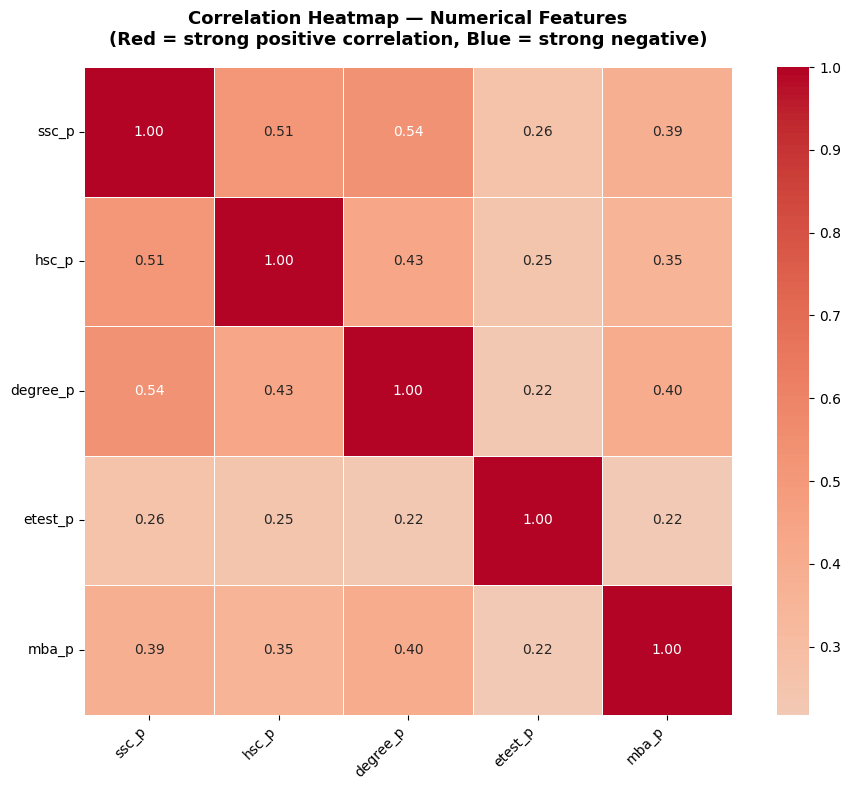

Correlation heatmap saved → C:\Users\DELL\OneDrive\Documents\GitHub\place-predictor\charts\correlation_heatmap.png

Key observations to mention in your viva:
  • Scores close to +1.0 → strong positive correlation (features move together)
  • Scores close to -1.0 → strong negative correlation
  • Scores near 0 → no linear relationship

Top 5 correlated feature pairs:
Feature A Feature B  Correlation
 degree_p     ssc_p     0.538404
    hsc_p     ssc_p     0.511472
 degree_p     hsc_p     0.434206
    mba_p  degree_p     0.402364
    mba_p     ssc_p     0.388478


In [26]:
%matplotlib inline

import seaborn as sns
import matplotlib.pyplot as plt


# Select only numerical columns for correlation analysis

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target if present
if 'status' in numerical_cols:
    numerical_cols.remove('status')

print(f"Numerical columns for heatmap: {numerical_cols}")

correlation_matrix = df[numerical_cols].corr()

# Plot the heatmap

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,           # Show correlation values inside cells
    fmt='.2f',            # Round to 2 decimal places
    cmap='coolwarm',      # Diverging colormap: blue = negative, red = positive
    center=0,             # White at zero correlation
    square=True,          # Equal aspect ratio for cleaner look
    linewidths=0.5,       # Grid lines between cells
    linecolor='white',
    annot_kws={'size': 10},
    ax=ax
)

ax.set_title(
    'Correlation Heatmap — Numerical Features\n'
    '(Red = strong positive correlation, Blue = strong negative)',
    fontsize=13,
    pad=16,
    weight='bold'
)

# Rotate axis labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()

# Save the chart
#chart_path = 'correlation_heatmap.png'
chart_path = "C:\\Users\\DELL\\OneDrive\\Documents\\GitHub\\place-predictor\\charts\\correlation_heatmap.png"
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show() 
plt.close()

print(f"Correlation heatmap saved → {chart_path}")
print()
print("Key observations to mention in your viva:")
print("  • Scores close to +1.0 → strong positive correlation (features move together)")
print("  • Scores close to -1.0 → strong negative correlation")
print("  • Scores near 0 → no linear relationship")

# Print top correlated pairs for discussion
import numpy as np
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Upper triangle only
pairs = (
    correlation_matrix
    .where(~mask)
    .stack()
    .reset_index()
)
pairs.columns = ['Feature A', 'Feature B', 'Correlation']
pairs['abs_corr'] = pairs['Correlation'].abs()
top_pairs = pairs.sort_values('abs_corr', ascending=False).head(5)
print()
print("Top 5 correlated feature pairs:")
print(top_pairs[['Feature A', 'Feature B', 'Correlation']].to_string(index=False))